# Pokémon GO Reviews — Exploratory Data Analysis

Comprehensive side-by-side EDA comparing two datasets scraped from the Google Play Store:

| Dataset | File | Ordering |
|---|---|---|
| **Newest** | `pokemon_go_reviews8.json` | Sorted by most recent |
| **Most Relevant** | `pokemon_go_reviews_most_relevant.json` | Sorted by relevance / helpfulness |

Sections covered:
1. Data loading & cleaning
2. Summary statistics
3. Star rating distributions
4. Helpful-count distributions
5. Review-length analysis
6. Temporal distribution
7. Scatter plots
8. Correlation analysis
9. Normality tests (Shapiro-Wilk, D'Agostino K², KS)
10. VIF (variance inflation factor)
11. Statistical significance tests between datasets


In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy statsmodels


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, normaltest, kstest, ks_2samp,
    mannwhitneyu, chi2_contingency, spearmanr, pearsonr
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

PALETTE = {"Newest": "#4C72B0", "Most Relevant": "#DD8452"}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

print("All imports OK")


All imports OK


In [3]:
DATA_DIR = Path(".")

def load_reviews(filename: str, label: str) -> pd.DataFrame:
    with open(DATA_DIR / filename, encoding="utf-8") as f:
        records = json.load(f)
    df = pd.DataFrame(records)
    df["dataset"] = label

    # Parse date
    df["date"] = pd.to_datetime(df["date"], format="%B %d, %Y", errors="coerce")

    # Derived features
    df["review_length"]   = df["review_text"].str.len()
    df["word_count"]      = df["review_text"].str.split().str.len()
    df["log_helpful"]     = np.log1p(df["helpful_count"])
    df["log_review_len"]  = np.log1p(df["review_length"])

    return df

df_new = load_reviews("pokemon_go_reviews8.json",            "Newest")
df_rel = load_reviews("pokemon_go_reviews_most_relevant.json", "Most Relevant")
df_all = pd.concat([df_new, df_rel], ignore_index=True)

print(f"Newest:       {len(df_new):>5} reviews")
print(f"Most Relevant:{len(df_rel):>5} reviews")
print(f"Combined:     {len(df_all):>5} reviews")
df_new.head(3)


Newest:       20100 reviews
Most Relevant:18280 reviews
Combined:     38380 reviews


,review_id,nickname,stars,date,review_text,helpful_count,dataset,review_length,word_count,log_helpful,log_review_len
0,16e074f3-2ab3-4669-9c83-59f8123abc72,Miles Gabuzda,5,2026-04-16,great game,0,Newest,10,2,0.0000,2.3979
1,8b9b2783-d7af-4c38-a40c-7c1fcfb56fa6,Colby Milisi,4,2026-04-16,fun but gets boring sorry,0,Newest,25,5,0.0000,3.2581
2,60588527-9541-4e16-900a-308aa691b07d,Amanda Childers,5,2026-04-16,can't get gigantic max pokemon and it kicked m...,0,Newest,72,16,0.0000,4.2905


## 1 · Data Overview & Basic Info


In [4]:
print("=" * 60)
print("NEWEST — dtypes & nulls")
print("=" * 60)
info_new = pd.DataFrame({
    "dtype":    df_new.dtypes,
    "non_null": df_new.notna().sum(),
    "null":     df_new.isna().sum(),
})
display(info_new)

print("\n" + "=" * 60)
print("MOST RELEVANT — dtypes & nulls")
print("=" * 60)
info_rel = pd.DataFrame({
    "dtype":    df_rel.dtypes,
    "non_null": df_rel.notna().sum(),
    "null":     df_rel.isna().sum(),
})
display(info_rel)


NEWEST — dtypes & nulls


,dtype,non_null,null
review_id,str,20100,0
nickname,str,20100,0
stars,int64,20100,0
date,datetime64[us],20100,0
review_text,str,20100,0
helpful_count,int64,20100,0
dataset,str,20100,0
review_length,int64,20100,0
word_count,int64,20100,0
log_helpful,float64,20100,0



MOST RELEVANT — dtypes & nulls


,dtype,non_null,null
review_id,str,18280,0
nickname,str,18280,0
stars,int64,18280,0
date,datetime64[us],18280,0
review_text,str,18280,0
helpful_count,int64,18280,0
dataset,str,18280,0
review_length,int64,18280,0
word_count,int64,18280,0
log_helpful,float64,18280,0


## 2 · Summary Statistics (Side-by-Side)


In [5]:
NUM_COLS = ["stars", "helpful_count", "review_length", "word_count"]

stats_new = df_new[NUM_COLS].describe(percentiles=[.25, .5, .75, .90, .95]).T
stats_rel = df_rel[NUM_COLS].describe(percentiles=[.25, .5, .75, .90, .95]).T

# Add skewness & kurtosis
for df_, stats_ in [(df_new, stats_new), (df_rel, stats_rel)]:
    stats_["skewness"] = df_[NUM_COLS].skew()
    stats_["kurtosis"] = df_[NUM_COLS].kurt()

combined = pd.concat(
    [stats_new, stats_rel],
    axis=1,
    keys=["Newest", "Most Relevant"]
)
display(combined.round(3))


Newest                                                    \
                   count     mean      std    min     25%     50%      75%   
stars         20100.0000   2.7440   1.7360 1.0000  1.0000  2.0000   5.0000   
helpful_count 20100.0000   6.7900  91.4940 0.0000  0.0000  0.0000   2.0000   
review_length 20100.0000 143.0850 138.6260 1.0000 35.0000 95.0000 207.0000   
word_count    20100.0000  27.1480  25.9870 1.0000  7.0000 18.0000  39.0000   

                                                             Most Relevant  \
                   90%      95%       max skewness  kurtosis         count   
stars           5.0000   5.0000    5.0000   0.2490   -1.6890    18280.0000   
helpful_count   5.0000  10.0000 9006.0000  58.1420 4974.5660    18280.0000   
review_length 376.0000 478.0000  737.0000   1.2040    0.4800    18280.0000   
word_count     70.0000  87.0000  133.0000   1.2010    0.5190    18280.0000   

                                                                             \
                  mean      std     min      25%      50%      75%      90%   
stars           2.5430   1.4810  1.0000   1.0000   2.0000   4.0000   5.0000   
helpful_count  25.9520 160.1950  0.0000   0.0000   2.0000   8.0000  31.0000   
review_length 367.4070 123.8360 26.0000 289.0000 367.0000 471.0000 497.0000   
word_count     68.9630  23.3570  4.0000  54.0000  69.0000  86.0000  94.0000   

                                                      
                   95%        max skewness  kurtosis  
stars           5.0000     5.0000   0.3790   -1.3140  
helpful_count  86.0500 10891.0000  31.9520 1765.2660  
review_length 499.0000  2717.0000   2.0800   32.8740  
word_count     98.0000   477.0000   1.8410   27.3050

## 3 · Star Rating Distributions


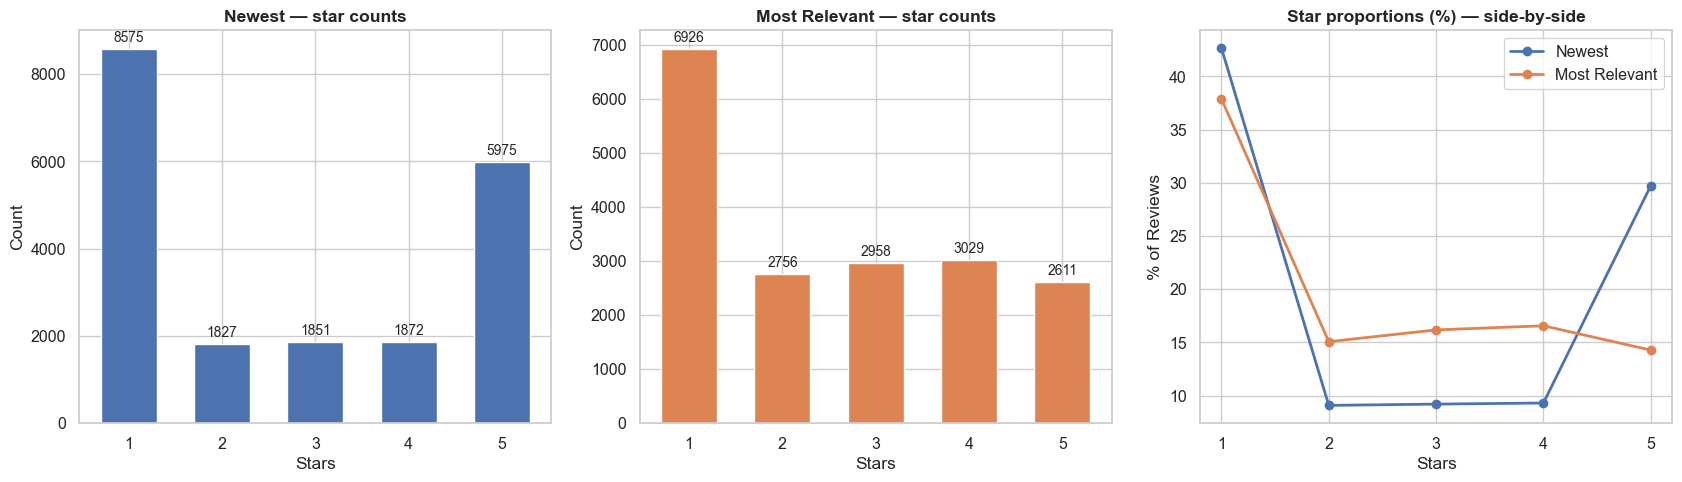

,Newest %,Most Relevant %
stars,,
1,42.6600,37.8900
2,9.0900,15.0800
3,9.2100,16.1800
4,9.3100,16.5700
5,29.7300,14.2800


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Absolute counts ---
for ax, (df_, label) in zip(axes[:2], [(df_new, "Newest"), (df_rel, "Most Relevant")]):
    counts = df_["stars"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=PALETTE[label], edgecolor="white", width=0.6)
    ax.bar_label(bars, padding=3, fontsize=10)
    ax.set_title(f"{label} — star counts", fontweight="bold")
    ax.set_xlabel("Stars"); ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])

# --- Proportions overlaid ---
for label, df_, color in [("Newest", df_new, PALETTE["Newest"]),
                           ("Most Relevant", df_rel, PALETTE["Most Relevant"])]:
    prop = df_["stars"].value_counts(normalize=True).sort_index()
    axes[2].plot(prop.index, prop.values * 100, marker="o", color=color, label=label, linewidth=2)
axes[2].set_title("Star proportions (%) — side-by-side", fontweight="bold")
axes[2].set_xlabel("Stars"); axes[2].set_ylabel("% of Reviews")
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].legend()

plt.tight_layout()
plt.savefig("star_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric proportion table
prop_new = df_new["stars"].value_counts(normalize=True).sort_index().rename("Newest %")
prop_rel = df_rel["stars"].value_counts(normalize=True).sort_index().rename("Most Relevant %")
display((pd.concat([prop_new, prop_rel], axis=1) * 100).round(2))


## 4 · Helpful-Count Distributions


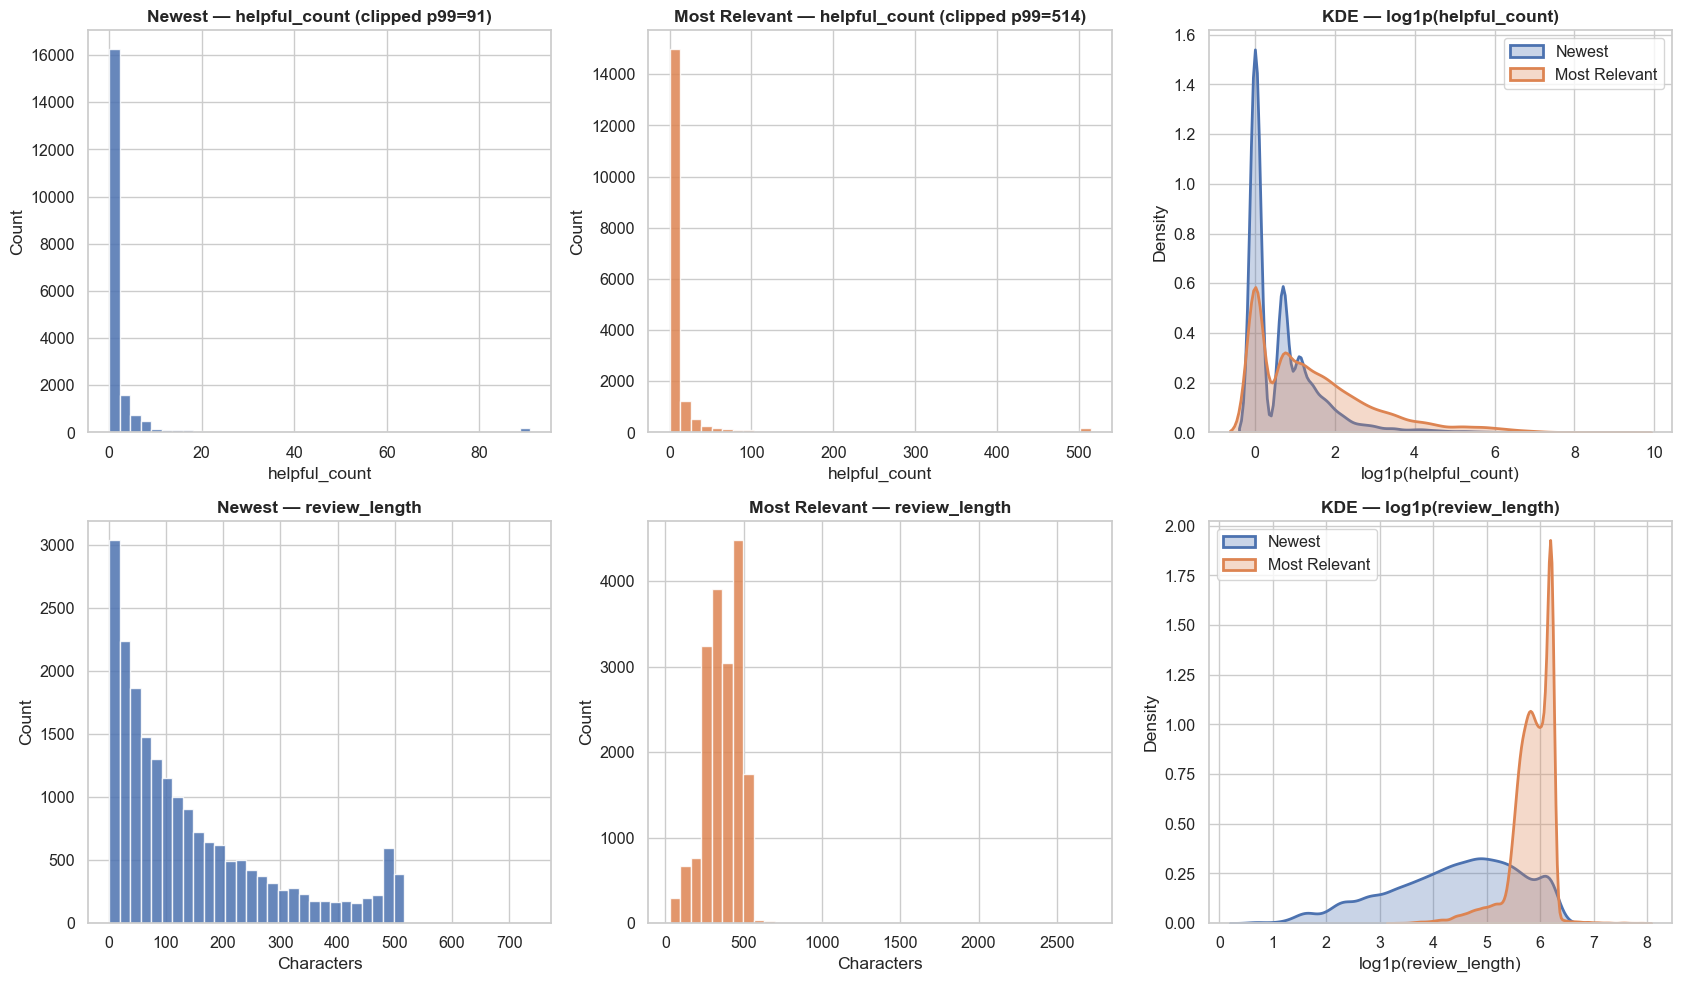

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

datasets = [("Newest", df_new), ("Most Relevant", df_rel)]

for col, (ax_hist, ax_box, ax_log) in zip(
    ["helpful_count", "helpful_count"],
    [(axes[0, 0], axes[0, 1], axes[0, 2]),
     (axes[1, 0], axes[1, 1], axes[1, 2])]
):
    pass  # replaced below

# Row 0 — raw helpful_count
for i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    # Histogram (clipped at 99th pct for visibility)
    clip = df_["helpful_count"].quantile(0.99)
    clipped = df_["helpful_count"].clip(upper=clip)
    axes[0, i].hist(clipped, bins=40, color=color, edgecolor="white", alpha=0.85)
    axes[0, i].set_title(f"{label} — helpful_count (clipped p99={clip:.0f})", fontweight="bold")
    axes[0, i].set_xlabel("helpful_count"); axes[0, i].set_ylabel("Count")

# Overlaid KDE of log1p(helpful_count)
for label, df_ in datasets:
    sns.kdeplot(df_["log_helpful"], ax=axes[0, 2], label=label, color=PALETTE[label], linewidth=2, fill=True, alpha=0.3)
axes[0, 2].set_title("KDE — log1p(helpful_count)", fontweight="bold")
axes[0, 2].set_xlabel("log1p(helpful_count)"); axes[0, 2].legend()

# Row 1 — review_length
for i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    axes[1, i].hist(df_["review_length"], bins=40, color=color, edgecolor="white", alpha=0.85)
    axes[1, i].set_title(f"{label} — review_length", fontweight="bold")
    axes[1, i].set_xlabel("Characters"); axes[1, i].set_ylabel("Count")

# Overlaid KDE of log review_length
for label, df_ in datasets:
    sns.kdeplot(df_["log_review_len"], ax=axes[1, 2], label=label, color=PALETTE[label], linewidth=2, fill=True, alpha=0.3)
axes[1, 2].set_title("KDE — log1p(review_length)", fontweight="bold")
axes[1, 2].set_xlabel("log1p(review_length)"); axes[1, 2].legend()

plt.tight_layout()
plt.savefig("helpful_review_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · Temporal Distribution


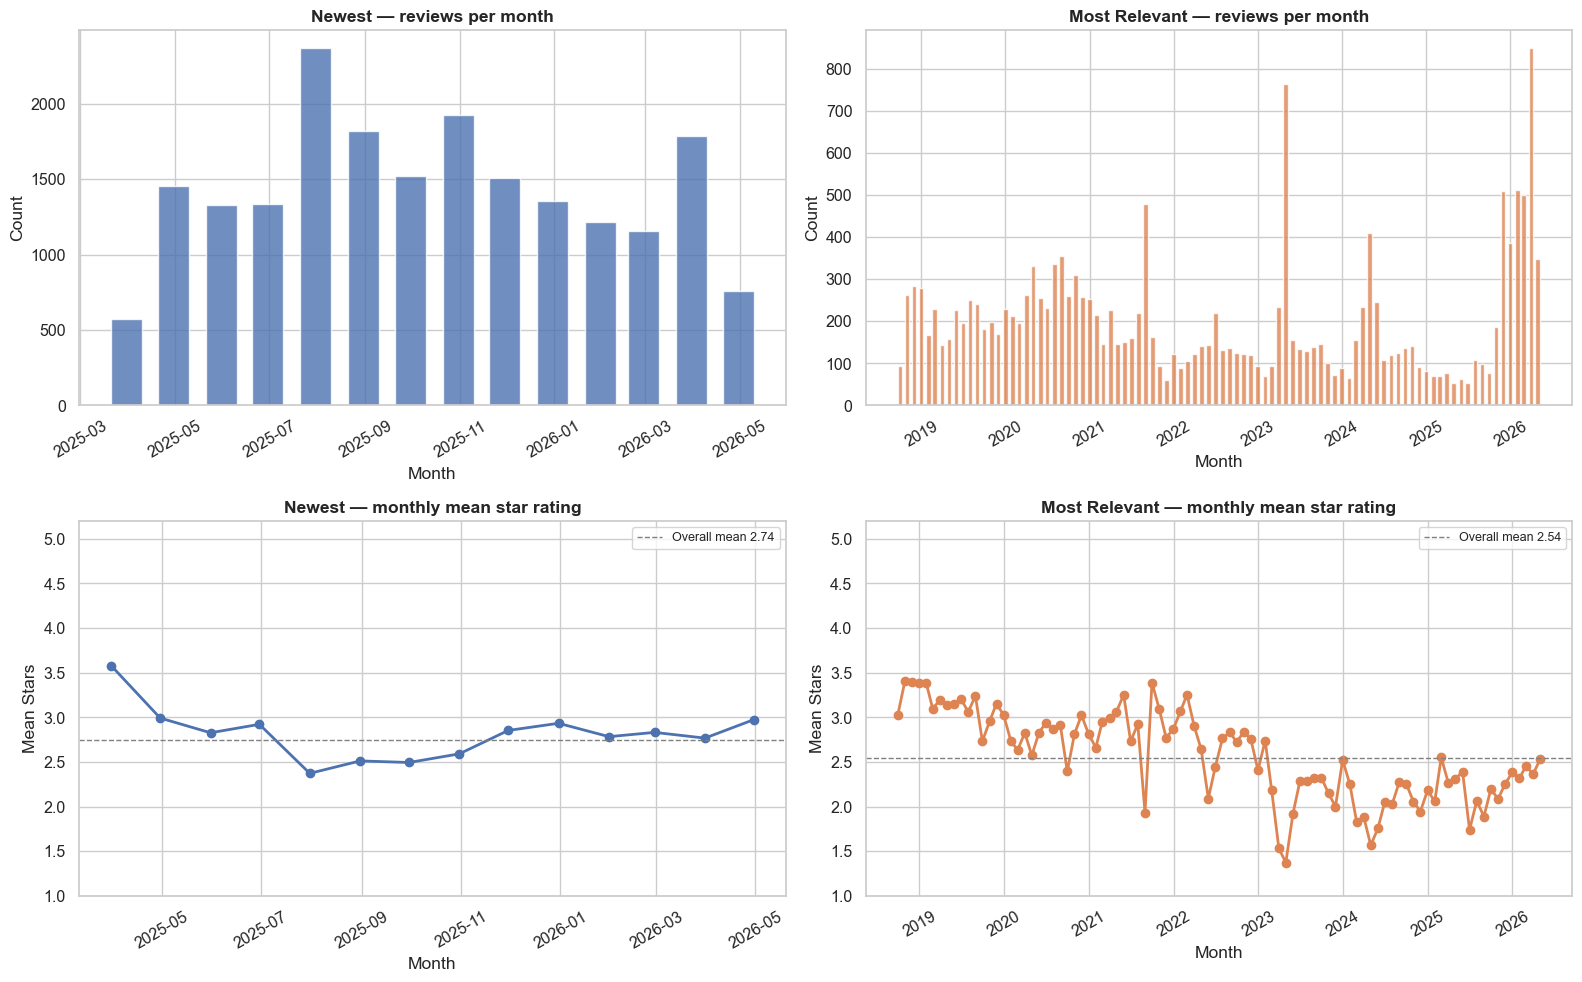

Date range — Newest:        2025-03-25 → 2026-04-16
Date range — Most Relevant: 2018-09-12 → 2026-04-16


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for (label, df_), ax_top, ax_bot in zip(
    datasets,
    [axes[0, 0], axes[0, 1]],
    [axes[1, 0], axes[1, 1]]
):
    color = PALETTE[label]

    # Monthly review count
    monthly = df_.set_index("date").resample("ME")["review_id"].count()
    ax_top.bar(monthly.index, monthly.values, color=color, width=20, alpha=0.8)
    ax_top.set_title(f"{label} — reviews per month", fontweight="bold")
    ax_top.set_xlabel("Month"); ax_top.set_ylabel("Count")
    ax_top.tick_params(axis="x", rotation=30)

    # Monthly mean star rating
    monthly_stars = df_.set_index("date").resample("ME")["stars"].mean()
    ax_bot.plot(monthly_stars.index, monthly_stars.values, color=color, marker="o", linewidth=2)
    ax_bot.axhline(df_["stars"].mean(), color="grey", linestyle="--", linewidth=1, label=f"Overall mean {df_['stars'].mean():.2f}")
    ax_bot.set_title(f"{label} — monthly mean star rating", fontweight="bold")
    ax_bot.set_xlabel("Month"); ax_bot.set_ylabel("Mean Stars")
    ax_bot.set_ylim(1, 5.2)
    ax_bot.legend(fontsize=9)
    ax_bot.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("temporal_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Date range — Newest:       ", df_new["date"].min().date(), "→", df_new["date"].max().date())
print("Date range — Most Relevant:", df_rel["date"].min().date(), "→", df_rel["date"].max().date())


## 6 · Box-plots & Violin Plots


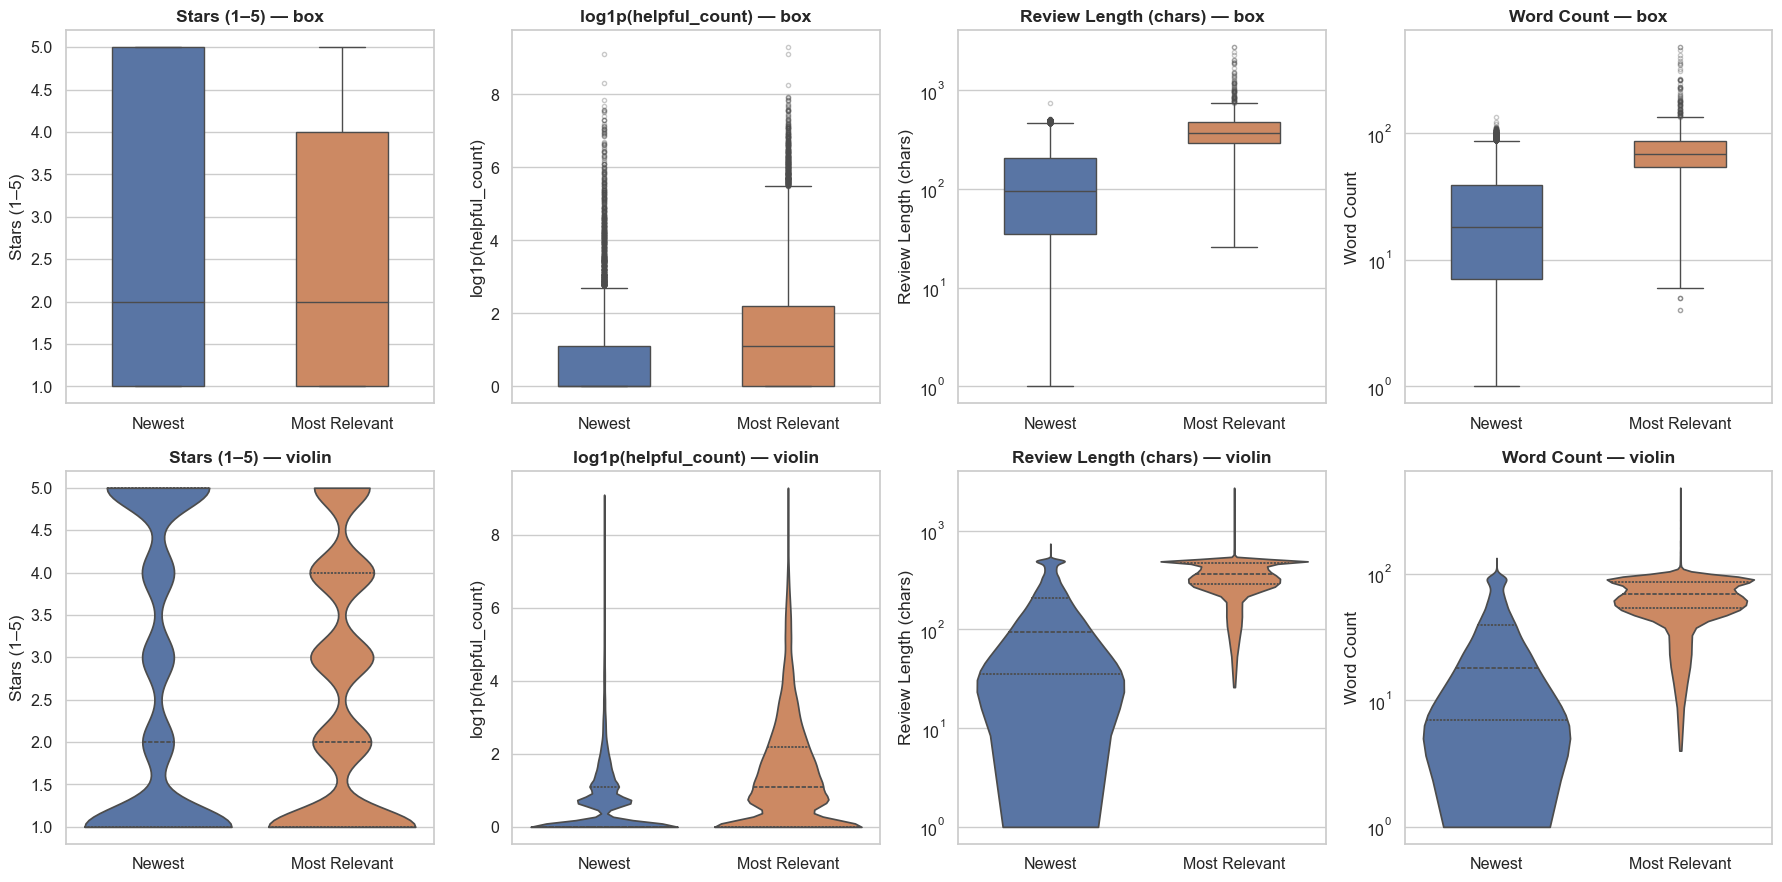

In [9]:
PLOT_VARS = [
    ("stars",          "Stars (1–5)",         False),
    ("log_helpful",    "log1p(helpful_count)", False),
    ("review_length",  "Review Length (chars)", True),
    ("word_count",     "Word Count",            True),
]

fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(18, 9))

for col_i, (var, label, use_log) in enumerate(PLOT_VARS):
    ax_box = axes[0, col_i]
    ax_vio = axes[1, col_i]

    data_plot = pd.concat([
        df_new[[var]].assign(Dataset="Newest"),
        df_rel[[var]].assign(Dataset="Most Relevant"),
    ])

    sns.boxplot(data=data_plot, x="Dataset", y=var, ax=ax_box,
                palette=PALETTE, width=0.5, flierprops={"marker": ".", "alpha": 0.3})
    ax_box.set_title(f"{label}", fontweight="bold")
    ax_box.set_xlabel(""); ax_box.set_ylabel(label)
    if use_log:
        ax_box.set_yscale("log")

    sns.violinplot(data=data_plot, x="Dataset", y=var, ax=ax_vio,
                   palette=PALETTE, inner="quartile", cut=0)
    ax_vio.set_xlabel(""); ax_vio.set_ylabel(label)
    if use_log:
        ax_vio.set_yscale("log")

axes[0, 0].set_title("Stars (1–5) — Boxplot", fontweight="bold")
axes[1, 0].set_title("Stars (1–5) — Violin", fontweight="bold")
for col_i, (_, label, _) in enumerate(PLOT_VARS):
    axes[0, col_i].set_title(f"{label} — box", fontweight="bold")
    axes[1, col_i].set_title(f"{label} — violin", fontweight="bold")

plt.tight_layout()
plt.savefig("boxplots_violins.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Scatter Plots


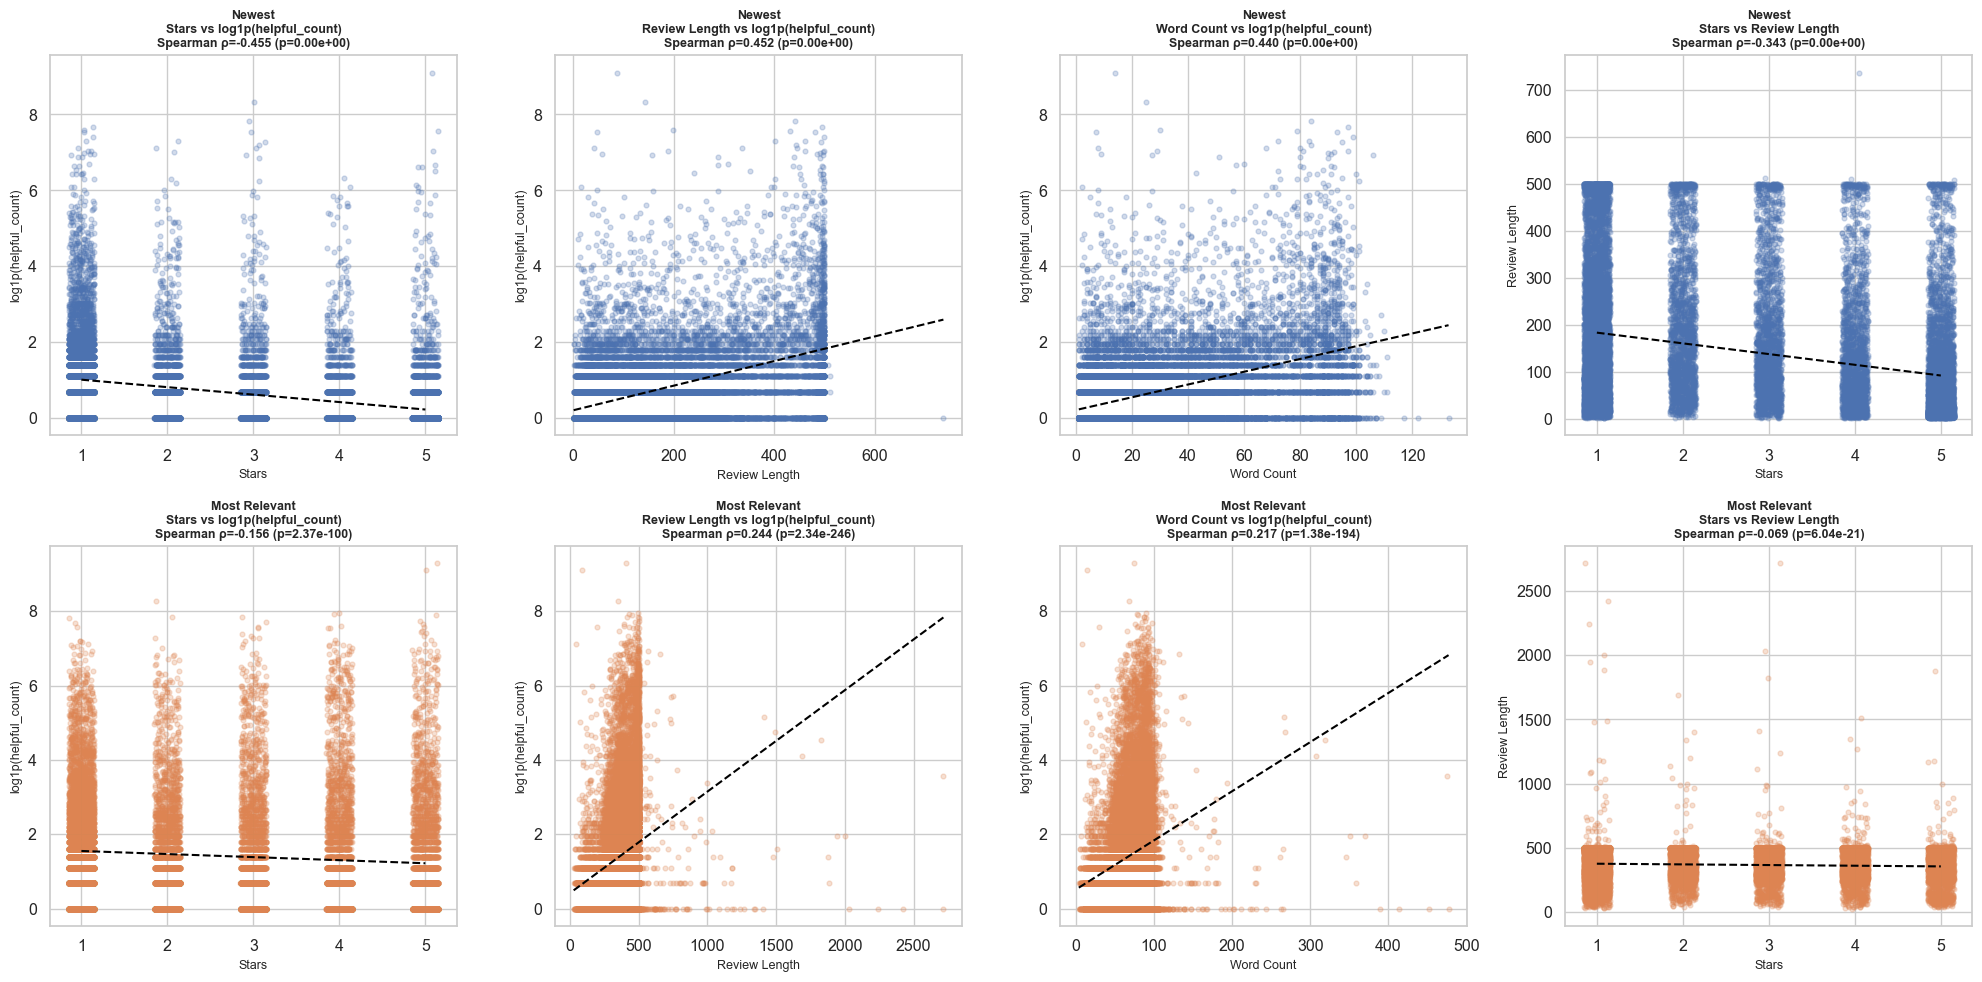

In [10]:
scatter_pairs = [
    ("stars",         "log_helpful",    "Stars",         "log1p(helpful_count)"),
    ("review_length", "log_helpful",    "Review Length", "log1p(helpful_count)"),
    ("word_count",    "log_helpful",    "Word Count",    "log1p(helpful_count)"),
    ("stars",         "review_length",  "Stars",         "Review Length"),
]

fig, axes = plt.subplots(2, len(scatter_pairs), figsize=(20, 10))

for col_i, (x_var, y_var, x_lbl, y_lbl) in enumerate(scatter_pairs):
    for row_i, (label, df_) in enumerate(datasets):
        ax = axes[row_i, col_i]
        color = PALETTE[label]

        # Jitter stars slightly to reduce overplotting
        x = df_[x_var] + (np.random.RandomState(42).uniform(-0.15, 0.15, len(df_)) if x_var == "stars" else 0)
        ax.scatter(x, df_[y_var], alpha=0.25, s=12, color=color)

        # Regression line
        mask = df_[x_var].notna() & df_[y_var].notna()
        m, b = np.polyfit(df_.loc[mask, x_var], df_.loc[mask, y_var], 1)
        xs = np.linspace(df_.loc[mask, x_var].min(), df_.loc[mask, x_var].max(), 100)
        ax.plot(xs, m * xs + b, color="black", linewidth=1.5, linestyle="--")

        rho, pval = spearmanr(df_.loc[mask, x_var], df_.loc[mask, y_var])
        ax.set_title(f"{label}\n{x_lbl} vs {y_lbl}\nSpearman ρ={rho:.3f} (p={pval:.2e})",
                     fontweight="bold", fontsize=9)
        ax.set_xlabel(x_lbl, fontsize=9)
        ax.set_ylabel(y_lbl, fontsize=9)

plt.tight_layout()
plt.savefig("scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Correlation Analysis (Pearson & Spearman)


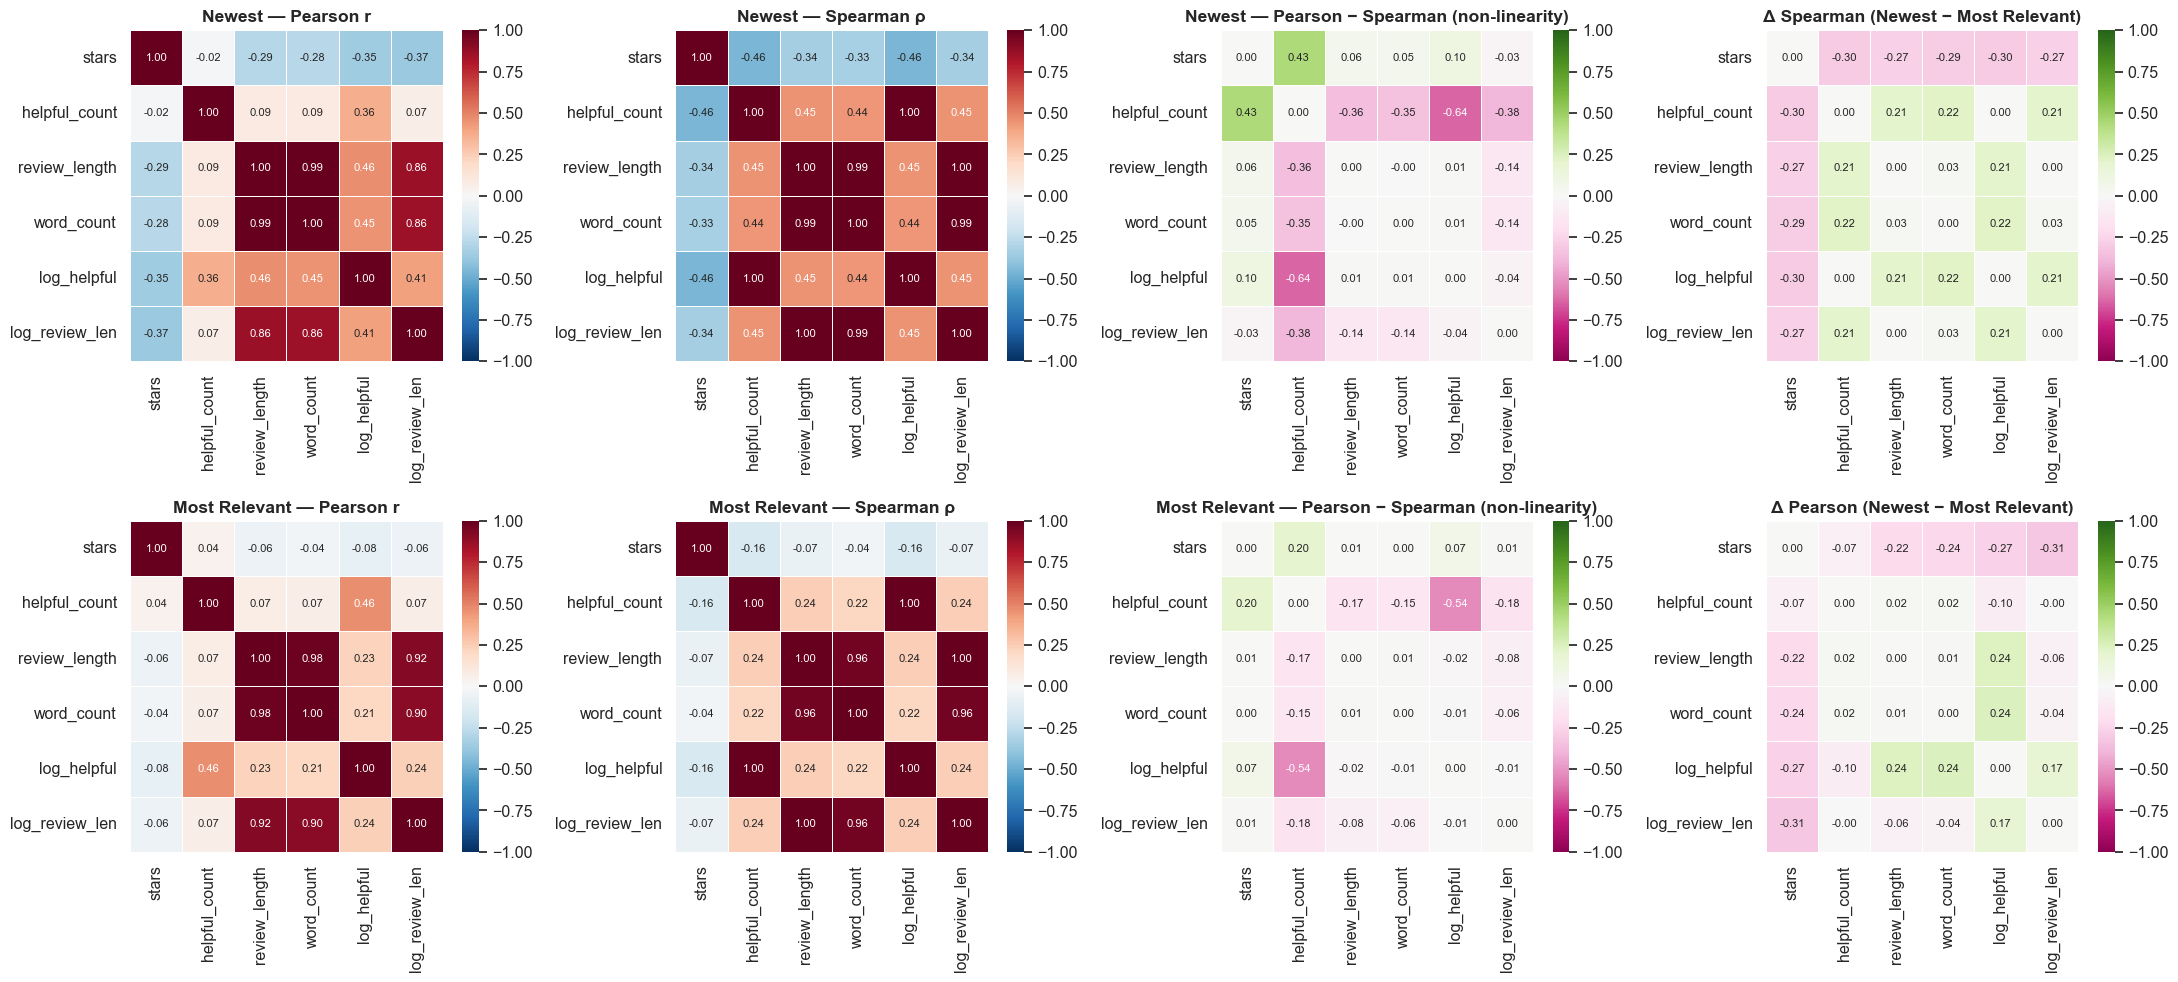

In [11]:
CORR_COLS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful", "log_review_len"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for ds_i, (label, df_) in enumerate(datasets):
    # Pearson
    pearson = df_[CORR_COLS].corr(method="pearson")
    sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                ax=axes[ds_i, 0], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 0].set_title(f"{label} — Pearson r", fontweight="bold")

    # Spearman
    spearman = df_[CORR_COLS].corr(method="spearman")
    sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                ax=axes[ds_i, 1], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 1].set_title(f"{label} — Spearman ρ", fontweight="bold")

    # Difference Pearson - Spearman (highlights non-linearity)
    diff = pearson - spearman
    sns.heatmap(diff, annot=True, fmt=".2f", cmap="PiYG", center=0,
                ax=axes[ds_i, 2], vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={"size": 8})
    axes[ds_i, 2].set_title(f"{label} — Pearson − Spearman (non-linearity)", fontweight="bold")

# Difference between datasets — Spearman
diff_ds = (df_new[CORR_COLS].corr(method="spearman") -
           df_rel[CORR_COLS].corr(method="spearman"))
sns.heatmap(diff_ds, annot=True, fmt=".2f", cmap="PiYG", center=0,
            ax=axes[0, 3], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8})
axes[0, 3].set_title("Δ Spearman (Newest − Most Relevant)", fontweight="bold")

diff_ds_p = (df_new[CORR_COLS].corr(method="pearson") -
             df_rel[CORR_COLS].corr(method="pearson"))
sns.heatmap(diff_ds_p, annot=True, fmt=".2f", cmap="PiYG", center=0,
            ax=axes[1, 3], vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 8})
axes[1, 3].set_title("Δ Pearson (Newest − Most Relevant)", fontweight="bold")

plt.tight_layout()
plt.savefig("correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · Normality Tests

Three complementary tests per variable per dataset:
- **Shapiro-Wilk** (most powerful for small samples; may be conservative for N > 5000)
- **D'Agostino K²** (`normaltest`) — combines skewness + kurtosis
- **Kolmogorov-Smirnov** (vs. a fitted normal) — non-parametric, no power issue with large N


In [12]:
NORM_COLS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful", "log_review_len"]

rows = []
for label, df_ in datasets:
    for col in NORM_COLS:
        x = df_[col].dropna().values
        # Shapiro-Wilk (subsample to 5000 max for speed/stability)
        x_sw = x if len(x) <= 5000 else np.random.RandomState(42).choice(x, 5000, replace=False)
        sw_stat, sw_p  = shapiro(x_sw)
        da_stat, da_p  = normaltest(x)
        # KS vs fitted normal
        ks_stat, ks_p  = kstest(x, "norm", args=(x.mean(), x.std(ddof=1)))

        rows.append({
            "Dataset":     label,
            "Variable":    col,
            "N":           len(x),
            "Skewness":    pd.Series(x).skew(),
            "Kurtosis":    pd.Series(x).kurt(),
            "SW stat":     sw_stat, "SW p-value":  sw_p,  "SW normal?": "✓" if sw_p > 0.05 else "✗",
            "DA stat":     da_stat, "DA p-value":  da_p,  "DA normal?": "✓" if da_p > 0.05 else "✗",
            "KS stat":     ks_stat, "KS p-value":  ks_p,  "KS normal?": "✓" if ks_p > 0.05 else "✗",
        })

norm_df = pd.DataFrame(rows)
display(norm_df.set_index(["Dataset", "Variable"]).round(4))


N  Skewness  Kurtosis  SW stat  SW p-value  \
Dataset       Variable                                                         
Newest        stars           20100    0.2491   -1.6889   0.7682      0.0000   
              helpful_count   20100   58.1418 4974.5661   0.0655      0.0000   
              review_length   20100    1.2039    0.4804   0.8452      0.0000   
              word_count      20100    1.2006    0.5186   0.8523      0.0000   
              log_helpful     20100    2.3692    8.2430   0.7070      0.0000   
              log_review_len  20100   -0.4974   -0.4544   0.9649      0.0000   
Most Relevant stars           18280    0.3789   -1.3135   0.8376      0.0000   
              helpful_count   18280   31.9516 1765.2656   0.2003      0.0000   
              review_length   18280    2.0804   32.8744   0.8215      0.0000   
              word_count      18280    1.8405   27.3050   0.8566      0.0000   
              log_helpful     18280    1.3087    1.6504   0.8576      0.0000   
              log_review_len  18280   -1.6699    4.9745   0.8417      0.0000   

                             SW normal?     DA stat  DA p-value DA normal?  \
Dataset       Variable                                                       
Newest        stars                   ✗  88123.6013      0.0000          ✗   
              helpful_count           ✗  66779.8506      0.0000          ✗   
              review_length           ✗   3243.4716      0.0000          ✗   
              word_count              ✗   3248.2211      0.0000          ✗   
              log_helpful             ✗  10259.5196      0.0000          ✗   
              log_review_len          ✗   1040.4353      0.0000          ✗   
Most Relevant stars                   ✗ 106830.4701      0.0000          ✗   
              helpful_count           ✗  48794.1899      0.0000          ✗   
              review_length           ✗  10982.4904      0.0000          ✗   
              word_count              ✗   9913.3255      0.0000          ✗   
              log_helpful             ✗   3857.6550      0.0000          ✗   
              log_review_len          ✗   6356.1149      0.0000          ✗   

                              KS stat  KS p-value KS normal?  
Dataset       Variable                                        
Newest        stars            0.2690      0.0000          ✗  
              helpful_count    0.4704      0.0000          ✗  
              review_length    0.1528      0.0000          ✗  
              word_count       0.1572      0.0000          ✗  
              log_helpful      0.2705      0.0000          ✗  
              log_review_len   0.0655      0.0000          ✗  
Most Relevant stars            0.2301      0.0000          ✗  
              helpful_count    0.4357      0.0000          ✗  
              review_length    0.1277      0.0000          ✗  
              word_count       0.0667      0.0000          ✗  
              log_helpful      0.1698      0.0000          ✗  
              log_review_len   0.1594      0.0000          ✗

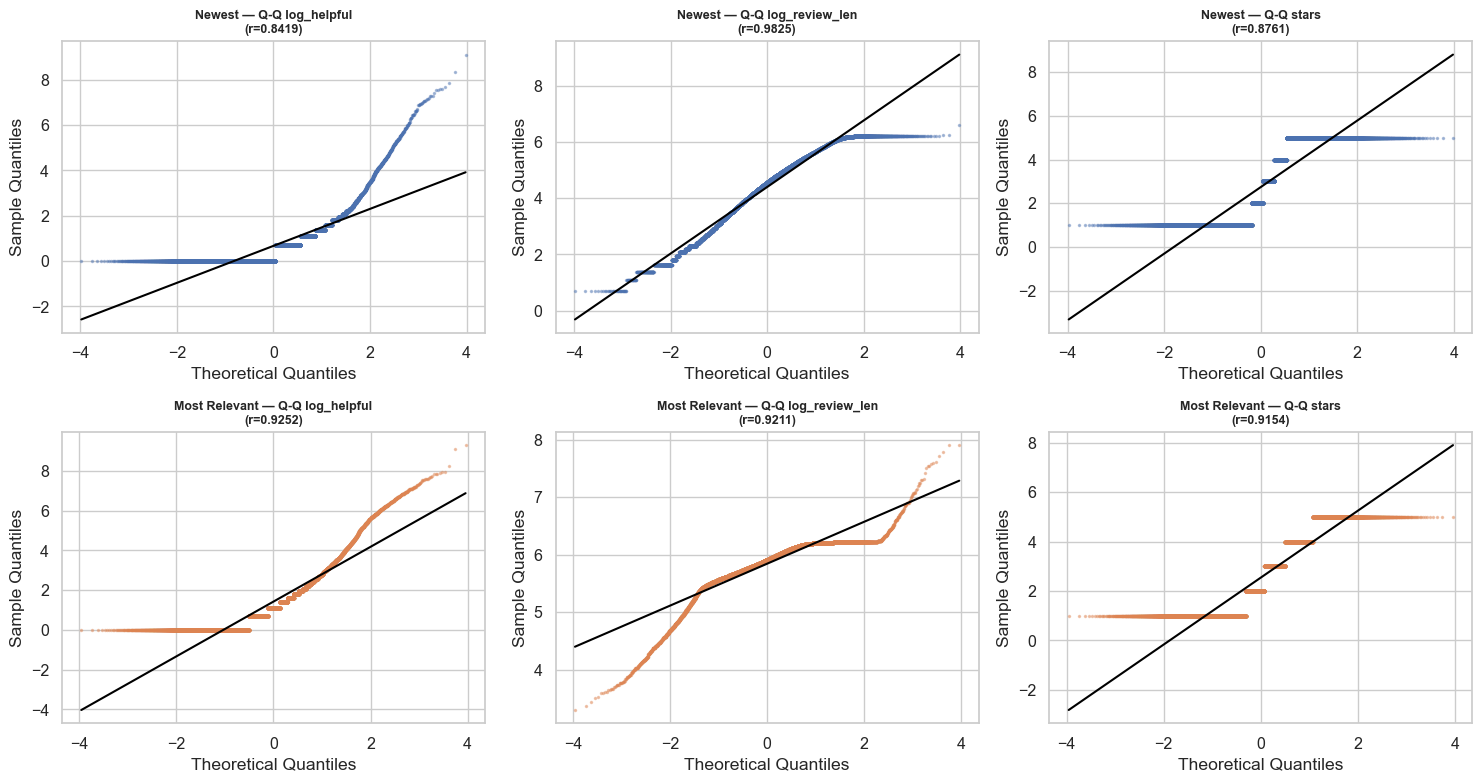

In [13]:
# Q-Q plots for log-transformed variables (closest to normal)
QQ_VARS = ["log_helpful", "log_review_len", "stars"]
fig, axes = plt.subplots(len(datasets), len(QQ_VARS), figsize=(15, 8))

for ds_i, (label, df_) in enumerate(datasets):
    color = PALETTE[label]
    for col_i, var in enumerate(QQ_VARS):
        ax = axes[ds_i, col_i]
        x = df_[var].dropna().values
        (osm, osr), (slope, intercept, r) = stats.probplot(x, dist="norm")
        ax.plot(osm, osr, ".", alpha=0.4, markersize=3, color=color)
        ax.plot(osm, slope * np.array(osm) + intercept, color="black", linewidth=1.5)
        ax.set_title(f"{label} — Q-Q {var}\n(r={r:.4f})", fontweight="bold", fontsize=9)
        ax.set_xlabel("Theoretical Quantiles"); ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.savefig("qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 · Variance Inflation Factor (VIF)

VIF measures multicollinearity among the numeric predictors.  
Rule of thumb: VIF > 5 signals moderate multicollinearity; VIF > 10 is severe.  
We treat `stars`, `review_length`, `word_count`, `log_helpful` as predictors.


,VIF (Newest),VIF (Most Relevant),Δ VIF
Feature,,,
review_length,73.8450,25.7270,48.1180
word_count,72.5650,25.4580,47.1080
log_helpful,1.3740,1.0640,0.3100
stars,1.1700,1.0250,0.1450


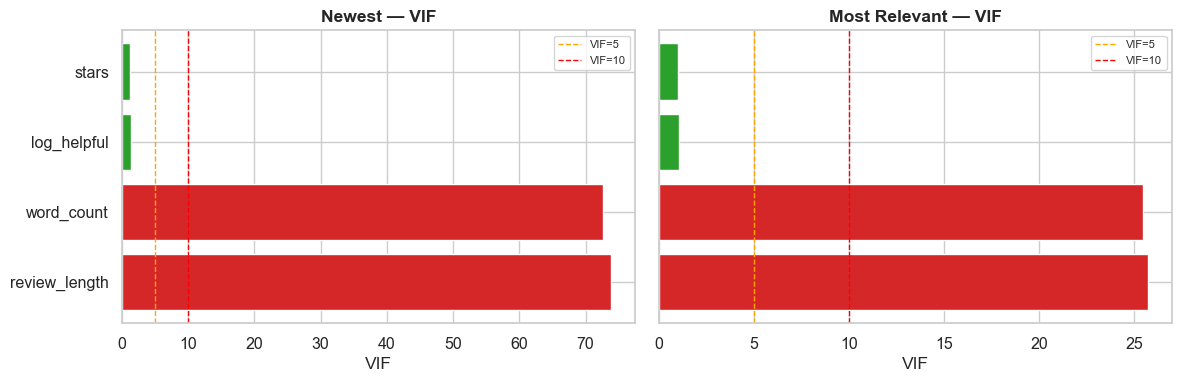

In [14]:
VIF_COLS = ["stars", "review_length", "word_count", "log_helpful"]

def compute_vif(df_: pd.DataFrame, cols: list) -> pd.DataFrame:
    X = df_[cols].dropna()
    # Add constant for intercept
    from statsmodels.tools.tools import add_constant
    X_const = add_constant(X)
    vif_data = pd.DataFrame({
        "Feature": cols,
        "VIF": [variance_inflation_factor(X_const.values, i + 1) for i in range(len(cols))],
    })
    return vif_data.sort_values("VIF", ascending=False)

vif_new = compute_vif(df_new, VIF_COLS).rename(columns={"VIF": "VIF (Newest)"})
vif_rel = compute_vif(df_rel, VIF_COLS).rename(columns={"VIF": "VIF (Most Relevant)"})

vif_combined = vif_new.merge(vif_rel, on="Feature")
vif_combined["Δ VIF"] = vif_combined["VIF (Newest)"] - vif_combined["VIF (Most Relevant)"]
display(vif_combined.set_index("Feature").round(3))

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, df_) in zip(axes, datasets):
    vif = compute_vif(df_, VIF_COLS)
    colors = ["#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c" for v in vif["VIF"]]
    ax.barh(vif["Feature"], vif["VIF"], color=colors)
    ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF=5")
    ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF=10")
    ax.set_title(f"{label} — VIF", fontweight="bold")
    ax.set_xlabel("VIF")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("vif.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Statistical Significance Tests Between the Two Datasets

Since normality is unlikely (skewed counts, ordinal ratings), we use **non-parametric** tests:

| Test | Variable | H₀ |
|---|---|---|
| **Chi-square** | `stars` (categorical) | The two datasets have the same star distribution |
| **Mann-Whitney U** | `helpful_count`, `review_length`, `word_count` | The two samples come from the same distribution |
| **Two-sample KS** | All numeric | The two samples have the same CDF |
| **Mood's median** | All numeric | The two samples have the same median |

Significance level α = 0.05.


In [16]:
from scipy.stats import median_test

ALPHA = 0.05
test_rows = []

# --- Chi-square on star counts ---
stars_all = pd.concat([
    df_new["stars"].reset_index(drop=True),
    df_rel["stars"].reset_index(drop=True),
], ignore_index=True)
dataset_labels = pd.Series(
    ["Newest"] * len(df_new) + ["Most Relevant"] * len(df_rel)
)
contingency = pd.crosstab(stars_all, dataset_labels)
chi2, chi_p, dof, _ = chi2_contingency(contingency)
test_rows.append({
    "Variable": "stars", "Test": "Chi-square (distribution)",
    "Statistic": chi2, "p-value": chi_p, "dof/n": dof,
    "Significant (α=0.05)": "YES ✓" if chi_p < ALPHA else "no",
})

# --- Mann-Whitney U + KS + Mood's median ---
TEST_VARS = ["stars", "helpful_count", "review_length", "word_count", "log_helpful"]

for var in TEST_VARS:
    a = df_new[var].dropna().values
    b = df_rel[var].dropna().values

    mw_stat, mw_p = mannwhitneyu(a, b, alternative="two-sided")
    ks_stat, ks_p = ks_2samp(a, b)
    try:
        _, mood_p, _, _ = median_test(a, b)
    except Exception:
        mood_p = float("nan")

    # Effect size: rank-biserial correlation for MWU
    n1, n2 = len(a), len(b)
    rb = 1 - (2 * mw_stat) / (n1 * n2)

    for test_name, stat, pval in [
        ("Mann-Whitney U", mw_stat, mw_p),
        ("Kolmogorov-Smirnov 2-sample", ks_stat, ks_p),
        ("Mood's Median",  None,    mood_p),
    ]:
        test_rows.append({
            "Variable": var,
            "Test": test_name,
            "Statistic": stat if stat is not None else "—",
            "p-value": pval,
            "dof/n": f"n₁={n1}, n₂={n2}",
            "Significant (α=0.05)": "YES ✓" if pval < ALPHA else "no",
            "Effect (rank-biserial r)": f"{rb:.4f}" if test_name == "Mann-Whitney U" else "—",
        })

results_df = pd.DataFrame(test_rows)
display(results_df.set_index(["Variable", "Test"]).round(4))


Statistic  p-value  \
Variable      Test                                                  
stars         Chi-square (distribution)        2128.1941   0.0000   
              Mann-Whitney U              193445505.5000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.1544   0.0000   
              Mood's Median                            —   0.0179   
helpful_count Mann-Whitney U              124851395.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.2568   0.0000   
              Mood's Median                            —   0.0000   
review_length Mann-Whitney U               45117333.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.6839   0.0000   
              Mood's Median                            —   0.0000   
word_count    Mann-Whitney U               45510943.5000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.6754   0.0000   
              Mood's Median                            —   0.0000   
log_helpful   Mann-Whitney U              124851395.0000   0.0000   
              Kolmogorov-Smirnov 2-sample         0.2568   0.0000   
              Mood's Median                            —   0.0000   

                                                        dof/n  \
Variable      Test                                              
stars         Chi-square (distribution)                     4   
              Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
helpful_count Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
review_length Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
word_count    Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   
log_helpful   Mann-Whitney U               n₁=20100, n₂=18280   
              Kolmogorov-Smirnov 2-sample  n₁=20100, n₂=18280   
              Mood's Median                n₁=20100, n₂=18280   

                                          Significant (α=0.05)  \
Variable      Test                                               
stars         Chi-square (distribution)                  YES ✓   
              Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
helpful_count Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
review_length Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
word_count    Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   
log_helpful   Mann-Whitney U                             YES ✓   
              Kolmogorov-Smirnov 2-sample                YES ✓   
              Mood's Median                              YES ✓   

                                          Effect (rank-biserial r)  
Variable      Test                                                  
stars         Chi-square (distribution)                        NaN  
              Mann-Whitney U                               -0.0530  
              Kolmogorov-Smirnov 2-sample                        —  
              Mood's Median                                      —  
helpful_count Mann-Whitney U  

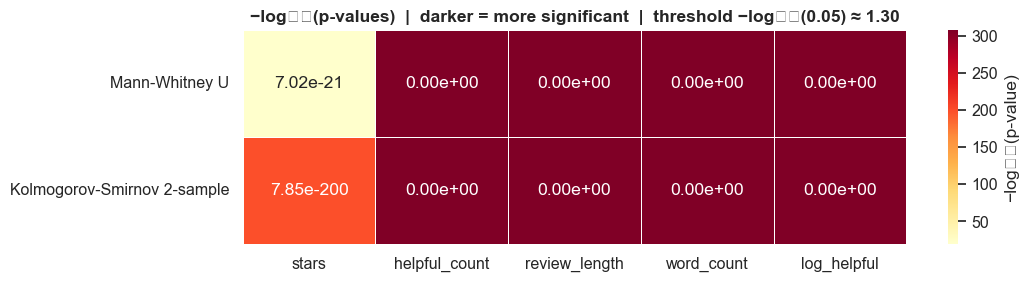

                             stars  helpful_count  review_length  word_count  log_helpful
Mann-Whitney U              0.0000         0.0000         0.0000      0.0000       0.0000
Kolmogorov-Smirnov 2-sample 0.0000         0.0000         0.0000      0.0000       0.0000


In [19]:
# Visual summary of p-values
sig_vars = ["stars", "helpful_count", "review_length", "word_count", "log_helpful"]
test_names_short = ["Mann-Whitney U", "Kolmogorov-Smirnov 2-sample"]

pval_matrix = pd.DataFrame(index=test_names_short, columns=sig_vars, dtype=float)
for var in sig_vars:
    a = df_new[var].dropna().values
    b = df_rel[var].dropna().values
    _, mw_p = mannwhitneyu(a, b, alternative="two-sided")
    _, ks_p = ks_2samp(a, b)
    pval_matrix.loc["Mann-Whitney U", var] = mw_p
    pval_matrix.loc["Kolmogorov-Smirnov 2-sample", var] = ks_p

pval_float = pval_matrix.astype(float)
# Clamp to machine epsilon to avoid -inf in log
pval_clamped = pval_float.clip(lower=np.finfo(float).tiny)
pval_log = -np.log10(pval_clamped)

# Annotation: scientific notation of actual p-values
annot_labels = pval_float.map(lambda x: f"{x:.2e}")

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(
    pval_log, annot=annot_labels, fmt="",
    cmap="YlOrRd", ax=ax, linewidths=0.5,
    cbar_kws={"label": "−log₁₀(p-value)"}
)
ax.set_title(
    "−log₁₀(p-values)  |  darker = more significant  |  threshold −log₁₀(0.05) ≈ 1.30",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("pvalue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(pval_float.to_string())


## 12 · Summary & Key Findings


In [20]:
print("=" * 70)
print("KEY FINDINGS SUMMARY")
print("=" * 70)

for label, df_ in datasets:
    stars_mean = df_["stars"].mean()
    stars_med  = df_["stars"].median()
    pct_5star  = (df_["stars"] == 5).mean() * 100
    pct_1star  = (df_["stars"] == 1).mean() * 100
    med_help   = df_["helpful_count"].median()
    max_help   = df_["helpful_count"].max()
    med_len    = df_["review_length"].median()

    print(f"\n{'─'*40}")
    print(f"  {label.upper()}")
    print(f"{'─'*40}")
    print(f"  N reviews:          {len(df_):>8,}")
    print(f"  Mean stars:         {stars_mean:>8.3f}")
    print(f"  Median stars:       {stars_med:>8.1f}")
    print(f"  % 5-star:           {pct_5star:>8.1f}%")
    print(f"  % 1-star:           {pct_1star:>8.1f}%")
    print(f"  Median helpful:     {med_help:>8.0f}")
    print(f"  Max helpful:        {max_help:>8,}")
    print(f"  Median review len:  {med_len:>8.0f} chars")
    date_range = f"{df_['date'].min().date()} → {df_['date'].max().date()}"
    print(f"  Date range:         {date_range}")

print(f"\n{'─'*40}")
print("  CROSS-DATASET COMPARISON")
print(f"{'─'*40}")
delta_mean = df_new["stars"].mean() - df_rel["stars"].mean()
print(f"  Δ mean stars (Newest − MostRel): {delta_mean:+.3f}")
delta_med_help = df_new["helpful_count"].median() - df_rel["helpful_count"].median()
print(f"  Δ median helpful (Newest − MostRel): {delta_med_help:+.0f}")

# Most relevant: do higher helpful_count reviews skew lower?
corr_rel, _ = spearmanr(df_rel["stars"], df_rel["helpful_count"])
corr_new, _ = spearmanr(df_new["stars"], df_new["helpful_count"])
print(f"  Spearman ρ(stars, helpful) — Newest:       {corr_new:.4f}")
print(f"  Spearman ρ(stars, helpful) — Most Relevant:{corr_rel:.4f}")


KEY FINDINGS SUMMARY

────────────────────────────────────────
  NEWEST
────────────────────────────────────────
  N reviews:            20,100
  Mean stars:            2.744
  Median stars:            2.0
  % 5-star:               29.7%
  % 1-star:               42.7%
  Median helpful:            0
  Max helpful:           9,006
  Median review len:        95 chars
  Date range:         2025-03-25 → 2026-04-16

────────────────────────────────────────
  MOST RELEVANT
────────────────────────────────────────
  N reviews:            18,280
  Mean stars:            2.543
  Median stars:            2.0
  % 5-star:               14.3%
  % 1-star:               37.9%
  Median helpful:            2
  Max helpful:          10,891
  Median review len:       367 chars
  Date range:         2018-09-12 → 2026-04-16

────────────────────────────────────────
  CROSS-DATASET COMPARISON
────────────────────────────────────────
  Δ mean stars (Newest − MostRel): +0.201
  Δ median helpful (Newest − Mos